In [182]:
# Load and merge
import pandas as pd

subject_data= pd.read_csv('/Users/pratheeekshamayajayaprasad/subject-info.csv')
test_data = pd.read_csv('/Users/pratheeekshamayajayaprasad/test_measure.csv')
merged_data = pd.merge(subject_data,test_data, on='ID')
print(merged_data)

         Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test_x  time  \
0       10.8    48.8   163.0      39.0         20.7    1  543     543_1     0   
1       10.8    48.8   163.0      39.0         20.7    1  543     543_1     3   
2       10.8    48.8   163.0      39.0         20.7    1  543     543_1    10   
3       10.8    48.8   163.0      39.0         20.7    1  543     543_1    13   
4       10.8    48.8   163.0      39.0         20.7    1  543     543_1    17   
...      ...     ...     ...       ...          ...  ...  ...       ...   ...   
773613  63.0    83.5   171.5      48.0         22.2    0  296     296_1   747   
773614  63.0    83.5   171.5      48.0         22.2    0  296     296_1   749   
773615  63.0    83.5   171.5      48.0         22.2    0  296     296_1   752   
773616  63.0    83.5   171.5      48.0         22.2    0  296     296_1   754   
773617  63.0    83.5   171.5      48.0         22.2    0  296     296_1   757   

        Speed     HR     VO

In [184]:
# 65. Calculate the percentage of male athletes who exceeded, the maximum treadmill speed of female athletes.

#step1: find max speed of female
female_merged_data= merged_data[merged_data['Sex'] == 1]
max_female_speed = female_merged_data['Speed'].max()

#step2: find max speed of male
Male_merged_data= merged_data[merged_data['Sex'] == 0]
max_Male_speed = Male_merged_data['Speed'].max()

#step3: find no of male athletes who exceeded maximum female speed.
Male_exceeding =Male_merged_data[Male_merged_data['Speed']>max_female_speed]

#step4: to remove duplicate ID
Male_exceeding_count = Male_exceeding['ID'].nunique()
Male_merged_data_count = Male_merged_data['ID'].nunique()
Percentage = Male_exceeding_count/Male_merged_data_count*100

print(Percentage)

9.641873278236915


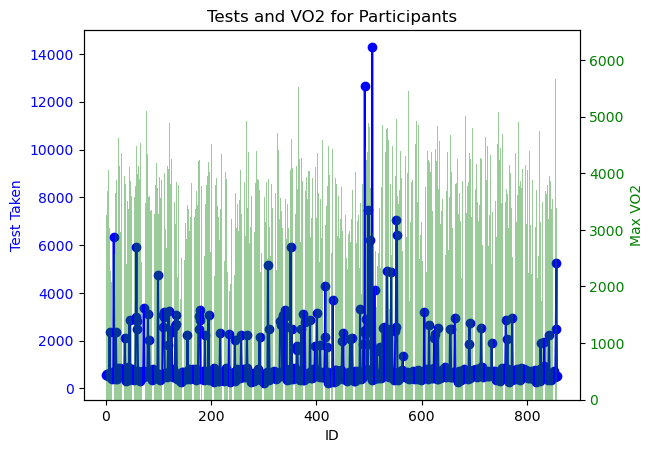

In [186]:
# 66. Visualize the number of test taken by participants and their trend of maximum Vo2 level as dual chart ?
tests_taken = merged_data.groupby('ID')['ID_test_x'].count().reset_index()
max_vo2 = merged_data.groupby('ID')['VO2'].max().reset_index()

# Create figure and first axis
fig, ax1 = plt.subplots()

# Plot on first y-axis
ax1.set_xlabel('ID')
ax1.set_ylabel('Test Taken', color='blue')
ax1.plot(tests_taken["ID"], tests_taken["ID_test_x"], color='blue', marker='o')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Max VO2', color='green')
ax2.bar(max_vo2["ID"], max_vo2["VO2"], color='green', alpha=0.4)
ax2.tick_params(axis='y', labelcolor='green')

# Title and show
plt.title('Tests and VO2 for Participants')
plt.show()

Text(0, 0.5, 'Speed')

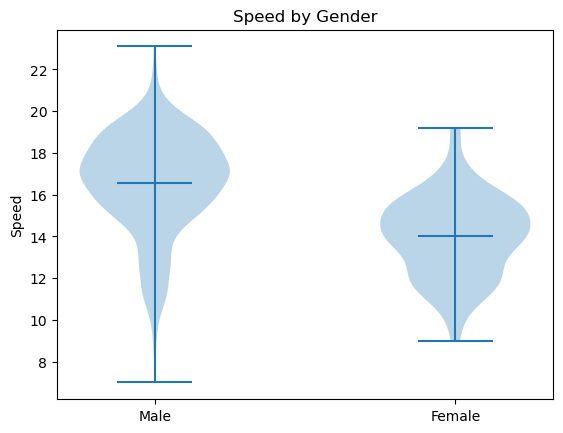

In [188]:
# 67. Create violin chart for any two column from the dataset ?

import matplotlib.pyplot as plt

max_male_speeds = Male_merged_data.groupby('ID')['Speed'].max().reset_index()
max_female_speeds = female_merged_data.groupby('ID')['Speed'].max().reset_index()

plt.violinplot([max_male_speeds["Speed"], max_female_speeds["Speed"]], showmeans=True)
plt.xticks([1, 2], ['Male', 'Female'])
plt.title('Speed by Gender')
plt.ylabel('Speed')

In [192]:
import numpy as np

# 68. calculate BSA (Body surface area) without using function and store as column in dataframe and categorize . 
merged_data['BSA'] = np.sqrt(merged_data['Height']*merged_data['Weight']/3600)

def categorize_bsa(value):
    if value < 1.5:
        return 'Low'
    elif 1.5 <= value <= 2.0:
        return 'Normal'
    else:
        return 'High'

merged_data['BSA_Category'] = merged_data['BSA'].apply(categorize_bsa)

# merged_data['BSA_Category_2'] = merged_data['BSA'].apply(
#     lambda x: 'Low' if x < 1.5 else ('Normal' if x <= 2.0 else 'High')
# )

print(merged_data)

         Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test_x  time  \
0       10.8    48.8   163.0      39.0         20.7    1  543     543_1     0   
1       10.8    48.8   163.0      39.0         20.7    1  543     543_1     3   
2       10.8    48.8   163.0      39.0         20.7    1  543     543_1    10   
3       10.8    48.8   163.0      39.0         20.7    1  543     543_1    13   
4       10.8    48.8   163.0      39.0         20.7    1  543     543_1    17   
...      ...     ...     ...       ...          ...  ...  ...       ...   ...   
773613  63.0    83.5   171.5      48.0         22.2    0  296     296_1   747   
773614  63.0    83.5   171.5      48.0         22.2    0  296     296_1   749   
773615  63.0    83.5   171.5      48.0         22.2    0  296     296_1   752   
773616  63.0    83.5   171.5      48.0         22.2    0  296     296_1   754   
773617  63.0    83.5   171.5      48.0         22.2    0  296     296_1   757   

        Speed     HR     VO

In [180]:
merged_data

,Age,Weight,Height,Humidity,Temperature,Sex,ID,ID_test_x,time,Speed,HR,VO2,VCO2,RR,VE,ID_test_y,BSA,BSA_Category,BSA_Category_2
0,10.8,48.8,163.0,39.0,20.7,1,543,543_1,0,0.0,NaN,585.0,566.0,13.0,21.5,543_1,1.486457,Low,Low
1,10.8,48.8,163.0,39.0,20.7,1,543,543_1,3,0.0,NaN,223.0,215.0,19.0,9.4,543_1,1.486457,Low,Low
2,10.8,48.8,163.0,39.0,20.7,1,543,543_1,10,0.0,58.0,309.0,302.0,9.0,10.5,543_1,1.486457,Low,Low
3,10.8,48.8,163.0,39.0,20.7,1,543,543_1,13,0.0,NaN,280.0,272.0,12.0,10.2,543_1,1.486457,Low,Low
4,10.8,48.8,163.0,39.0,20.7,1,543,543_1,17,0.0,96.0,294.0,283.0,13.0,10.6,543_1,1.486457,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
773613,63.0,83.5,171.5,48.0,22.2,0,296,296_1,747,5.0,109.0,1346.0,1569.0,24.0,55.3,296_1,1.994454,Normal,Normal
773614,63.0,83.5,171.5,48.0,22.2,0,296,296_1,749,5.0,109.0,1346.0,1561.0,24.0,54.7,296_1,1.994454,Normal,Normal
773615,63.0,83.5,171.5,48.0,22.2,0,296,296_1,752,5.0,109.0,1381.0,1578.0,24.0,54.5,296_1,1.994454,Normal,Normal
773616,63.0,83.5,171.5,48.0,22.2,0,296,296_1,754,5.0,110.0,1356.0,1533.0,24.0,52.9,296_1,1.994454,Normal,Normal
